In [1]:
# --- Step 1: Clean and Install Working RDKit Build ---
!pip install rdkit --quiet
!pip install scikit-learn tqdm joblib --quiet

# Validate RDKit
from rdkit import Chem
from rdkit.Chem import AllChem
print("✅ RDKit imported successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 35.1 MB/s eta 0:00:00:00:0100:01
✅ RDKit imported successfully.


In [2]:
import pandas as pd
ddi_df = pd.read_feather("/kaggle/input/healthcare-ddi-dfi/ddi_rulesF.feather")
ddi_df.shape

(2855848, 2)

In [3]:
ddi_df.head()

,drug_a_id,drug_b_id
0,DB00001,DB06605
1,DB00001,DB06695
2,DB00001,DB01254
3,DB00001,DB01609
4,DB00001,DB01586


In [4]:
drugs_df = pd.read_csv("/kaggle/input/healthcare-ddi-dfi/drugs.csv")
drugs_df.head()

,drugbank_id,name,synonyms,smiles,atc_code,description,drug_groups,categories,kingdom,superclass,...,subclass,target_ids,enzyme_ids,carrier_ids,transporter_ids,indication,mechanism_of_action,metabolism,toxicity,half_life
0,DB00001,Lepirudin,"[Leu1, Thr2]-63-desulfohirudin; Desulfatohirud...",NaN,B01AE02,Lepirudin is a recombinant hirudin formed by 6...,approved; withdrawn,"Amino Acids, Peptides, and Proteins; Anticoagu...",Organic Compounds,Organic Acids,...,"Amino Acids, Peptides, and Analogues",BE0000048,NaN,NaN,NaN,Lepirudin is indicated for anticoagulation in ...,Lepirudin is a direct thrombin inhibitor used ...,"As a polypeptide, lepirudin is expected to be ...",The acute toxicity of intravenous lepirudin wa...,Lepirudin has an initial half-life of approxim...
1,DB00002,Cetuximab,Cetuximab; Cétuximab; Cetuximabum,NaN,L01FE01,Cetuximab is a recombinant chimeric human/mous...,approved,"Amino Acids, Peptides, and Proteins; Antibodie...",Organic Compounds,Organic Acids,...,"Amino Acids, Peptides, and Analogues",BE0000767; BE0000901; BE0002094; BE0002095; BE...,NaN,NaN,NaN,Cetuximab indicated for the treatment of local...,The epidermal growth factor receptor (EGFR) is...,"Like other monoclonal antibodies, cetuximab is...",The intravenous LD<sub>50</sub> is > 300 mg/kg...,After administration of a 400 mg/m<sup>2</sup>...
2,DB00003,Dornase alfa,Deoxyribonuclease (human clone 18-1 protein mo...,NaN,R05CB13,Dornase alfa is a biosynthetic form of human d...,approved,"Amino Acids, Peptides, and Proteins; Cough and...",Organic Compounds,Organic Acids,...,"Amino Acids, Peptides, and Analogues",BE0012829,NaN,NaN,NaN,Used as adjunct therapy in the treatment of cy...,Dornase alfa is a biosynthetic form of human D...,While no conclusive studies have yet been publ...,Adverse reactions occur at a frequency of < 1/...,NaN
3,DB00004,Denileukin diftitox,DAB(SUB 389)IL2; Denileukin; Denileukin diftit...,NaN,L01XX29,Denileukin diftitox is an IL2-receptor-directe...,approved; investigational,"ADP Ribose Transferases; Amino Acids, Peptides...",Organic Compounds,Organic Acids,...,"Amino Acids, Peptides, and Analogues",BE0000658; BE0000651,NaN,NaN,NaN,Denileukin diftitox was previously indicated f...,Denileukin diftitox is a fusion protein compos...,Denileukin diftitox is expected to be metaboli...,There is limited information regarding the acu...,The arithmetic mean (CV%) denileukin diftitox ...
4,DB00005,Etanercept,Etanercept; etanercept-szzs; etanercept-ykro; ...,NaN,L04AB01,Dimeric fusion protein consisting of the extra...,approved; investigational,"Agents reducing cytokine levels; Amino Acids, ...",Organic Compounds,Organic Acids,...,"Amino Acids, Peptides, and Analogues",BE0000704; BE0001087; BE0000710; BE0002098; BE...,NaN,NaN,NaN,Etanercept is indicated for the treatment of m...,There are two distinct receptors for TNF (TNFR...,"As etanercept is a fusion protein antibody, it...",NaN,Etanercept has a mean half-life of elimination...


In [5]:
drugs_df.shape

(17430, 21)

In [6]:
# --- Step 2: Load & Preprocess Datasets ---

import pandas as pd

# Load drug info and DDI rules
#drugs_df = pd.read_csv("drugs.csv")
#ddi_df = pd.read_csv("ddi_rules_clean.csv")

# Keep only drugs with SMILES
usable_drugs = drugs_df[drugs_df['smiles'].notna()][['drugbank_id','smiles']]
usable_drugs.set_index('drugbank_id', inplace=True)

print(f"Total Drugs in Database: {len(drugs_df)}")
print(f"Usable Drugs with SMILES: {len(usable_drugs)} ({len(usable_drugs)/len(drugs_df):.2%})")

# Filter DDIs so both drugs have SMILES
ddi_df = ddi_df[
    ddi_df['drug_a_id'].isin(usable_drugs.index) &
    ddi_df['drug_b_id'].isin(usable_drugs.index)
].drop_duplicates(subset=['drug_a_id', 'drug_b_id'])

print(f"Filtered DDI pairs available for training: {len(ddi_df)}")


Total Drugs in Database: 17430
Usable Drugs with SMILES: 12313 (70.64%)
Filtered DDI pairs available for training: 2323786


In [7]:
# --- Step 3: Generate RDKit Fingerprints ---

from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
from tqdm import tqdm

from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# Create the generator once
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

def mol_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((1,))
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


# Precompute all drug fingerprints
print("Generating molecular fingerprints for usable drugs...")
fingerprints = {}
for dbid, row in tqdm(usable_drugs.iterrows(), total=len(usable_drugs)):
    smiles = row['smiles']
    fp = mol_to_fp(smiles)
    if fp is not None:
        fingerprints[dbid] = fp

print(f"✅ Generated fingerprints for {len(fingerprints)} drugs.")


Generating molecular fingerprints for usable drugs...


 14%|█▍        | 1709/12313 [00:00<00:05, 1913.88it/s][14:36:55] SMILES Parse Error: syntax error while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[14:36:55] SMILES Parse Error: check for mistakes around position 84:
[14:36:55] C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O
[14:36:55] ~~~~~~~~~~~~~~~~~~~~^
[14:36:55] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[14:36:55] SMILES Parse Error: check for mistakes around position 40:
[14:36:55] 1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2
[14:36:55] ~~~~~~~~~~~~~~~~~~~~^
[14:36:55] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(

✅ Generated fingerprints for 12303 drugs.


In [8]:
from tqdm import tqdm
import random

# --- Step 4: Create Training Pairs (Positive + Negative) ---

# (A) Build positive pairs and the positive set
positive_pairs = []
positive_set = set()
for _, row in tqdm(ddi_df.iterrows(), total=len(ddi_df)):
    a, b = row['drug_a_id'], row['drug_b_id']
    if a in fingerprints and b in fingerprints:
        pair = frozenset([a, b])
        if pair not in positive_set:
            positive_set.add(pair)
            positive_pairs.append((a, b, 1))

print(f"✅ Positive pairs collected: {len(positive_pairs)}")

# (B) Build negative pairs (random non-DDIs, not in positive set)
all_ids = list(fingerprints.keys())
negative_pairs = []
negative_needed = len(positive_pairs)

pbar = tqdm(total=negative_needed)
while len(negative_pairs) < negative_needed:
    a, b = random.sample(all_ids, 2)
    pair = frozenset([a, b])
    if pair not in positive_set:
        negative_pairs.append((a, b, 0))
        positive_set.add(pair)  # Prevent reuse as negative
        pbar.update(1)
pbar.close()

print(f"✅ Negative pairs generated: {len(negative_pairs)}")

# (C) Combine and shuffle
dataset = positive_pairs + negative_pairs
random.shuffle(dataset)
print(f"Training dataset size: {len(dataset)} (Positives: {len(positive_pairs)}, Negatives: {len(negative_pairs)})")


100%|██████████| 2323786/2323786 [01:54<00:00, 20242.73it/s]


✅ Positive pairs collected: 1161857


100%|██████████| 1161857/1161857 [00:07<00:00, 146698.53it/s]


✅ Negative pairs generated: 1161857
Training dataset size: 2323714 (Positives: 1161857, Negatives: 1161857)


In [9]:
print(f"Dataset size: {len(dataset)}")

Dataset size: 2323714


In [10]:
import random

N = 500000  # choose the number based on your Colab RAM capacity
dataset = random.sample(dataset, N)
print(f"Using {N} pairs for ML (randomly sampled).")


Using 500000 pairs for ML (randomly sampled).


In [11]:
    
# --- Step 5: Feature Vector Construction ---

X, y = [], []
for a, b, label in tqdm(dataset):
    fp_a, fp_b = fingerprints[a], fingerprints[b]
    combined = np.concatenate([fp_a, fp_b])  # simple concatenation
    X.append(combined)
    y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)
print(f"Feature matrix shape: {X.shape}")


100%|██████████| 500000/500000 [00:23<00:00, 21635.01it/s]


Feature matrix shape: (500000, 4096)


In [12]:
# --- Step 6: Train Random Forest Model ---

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
import joblib

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Random Forest model...")
rf = RandomForestClassifier(
    n_estimators=200, max_depth=20, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

# Evaluate model
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("✅ Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Training Random Forest model...
✅ Model Performance:
Accuracy: 0.8676
ROC AUC: 0.9376317845336853

Classification report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86     49676
           1       0.85      0.90      0.87     50324

    accuracy                           0.87    100000
   macro avg       0.87      0.87      0.87    100000
weighted avg       0.87      0.87      0.87    100000



In [13]:
# --- Step 7: Save Trained Model ---

joblib.dump(rf, "ddi_rf_model.pkl")
print("✅ Model saved as 'ddi_rf_model_Big500k.pkl'")


✅ Model saved as 'ddi_rf_model_Big500k.pkl'


In [14]:
# --- Step 8: Test a Prediction ---

def predict_interaction_from_smiles(smiles_a, smiles_b):
    molA, molB = Chem.MolFromSmiles(smiles_a), Chem.MolFromSmiles(smiles_b)
    if molA is None or molB is None:
        return "Invalid SMILES input."
    fpA = mol_to_fp(smiles_a)
    fpB = mol_to_fp(smiles_b)
    features = np.concatenate([fpA, fpB]).reshape(1, -1)
    prob = rf.predict_proba(features)[0][1]
    risk = "High" if prob >= 0.75 else "Moderate" if prob >= 0.5 else "Low"
    print(f"Predicted Interaction Probability: {prob:.3f} → Risk Level: {risk}")

# Example test case: Warfarin & Simvastatin
warfarin = usable_drugs.loc["DB00682", "smiles"]
simvastatin = usable_drugs.loc["DB00641", "smiles"]
predict_interaction_from_smiles(warfarin, simvastatin)


Predicted Interaction Probability: 0.607 → Risk Level: Moderate


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

# 1. Feature Importances Plot


def plot_feature_importance(model, top_n=20):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]
    plt.figure(figsize=(12,7))
    plt.title("Top {} Molecular Fingerprint Bit Importances".format(top_n))
    plt.barh(range(top_n), importances[indices], align='center', color='royalblue')
    plt.yticks(range(top_n), indices)
    plt.xlabel("Relative Importance (fraction of total)")
    plt.ylabel("Fingerprint Bit Index")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    print("Interpretation: Each y-axis number is a fingerprint feature index. 'Relative Importance' quantifies how much this feature bit influences the Random Forest’s decision for predicting DDIs. High values indicate these molecular fragments are key predictors.")


# 2. ROC Curve Plot
def plot_roc_curve(y_true, y_probs):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend()
    plt.show()

# 3. Precision-Recall Curve Plot
def plot_precision_recall(y_true, y_probs):
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    plt.figure(figsize=(8, 6))
    plt.step(recall, precision, where='post')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall curve')
    plt.show()

# 4. Confusion Matrix Plot
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

# 5. Prediction Probability Distribution (High vs Low Risk)
def plot_pred_prob_histogram(y_true, y_probs):
    plt.figure(figsize=(8,6))
    sns.histplot(y_probs[y_true==1], color='red', label='Positive Label', kde=True, stat='density')
    sns.histplot(y_probs[y_true==0], color='green', label='Negative Label', kde=True, stat='density')
    plt.legend()
    plt.xlabel('Predicted Probability')
    plt.ylabel('Density')
    plt.title('Histogram of Predicted Probabilities')
    plt.show()

# 6. Training Curve (if available)
def plot_training_curve(train_scores, val_scores):
    plt.figure(figsize=(8,6))
    plt.plot(train_scores, label='Training Score')
    plt.plot(val_scores, label='Validation Score')
    plt.xlabel('Training Iterations')
    plt.ylabel('Score')
    plt.title('Training Curve')
    plt.legend()
    plt.show()


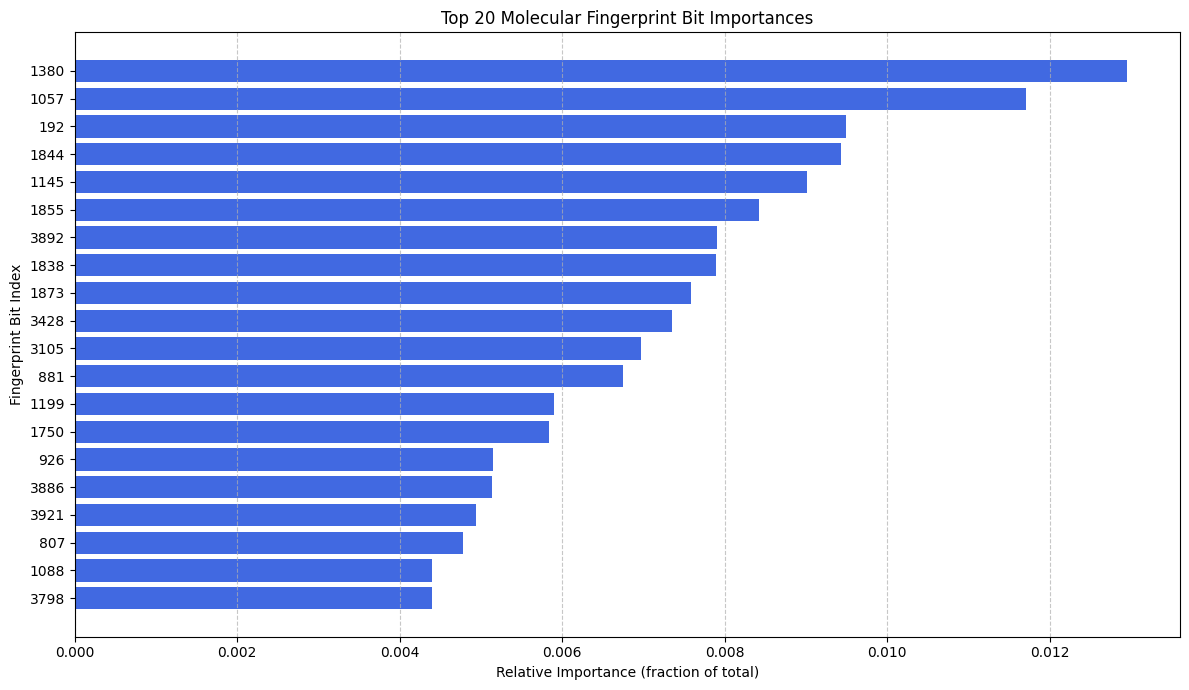

Interpretation: Each y-axis number is a fingerprint feature index. 'Relative Importance' quantifies how much this feature bit influences the Random Forest’s decision for predicting DDIs. High values indicate these molecular fragments are key predictors.


In [19]:
# 1. Feature importance
plot_feature_importance(rf)

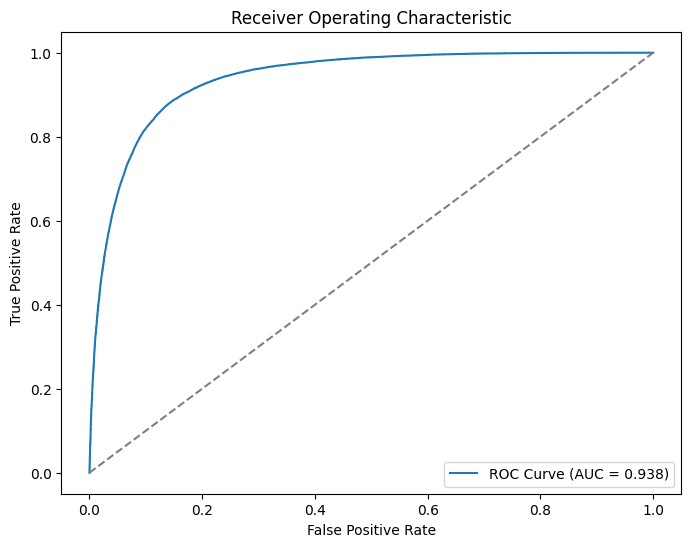

In [20]:
# 2. ROC Curve
plot_roc_curve(y_test, y_prob)


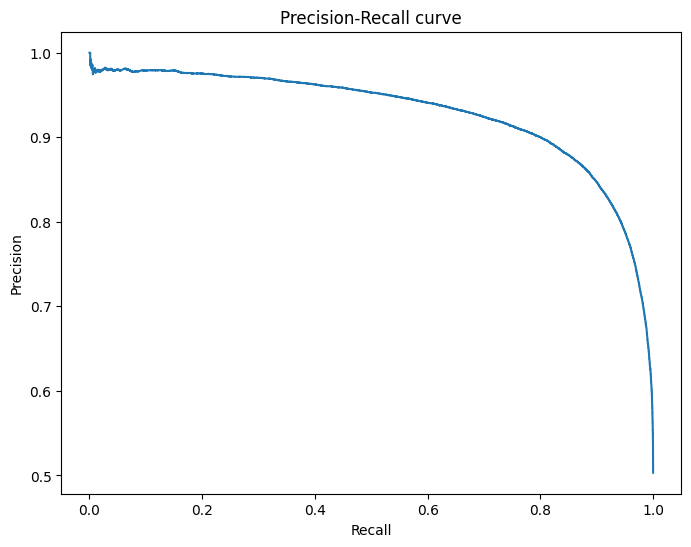

In [21]:
# 3. Precision-Recall Curve
plot_precision_recall(y_test, y_prob)


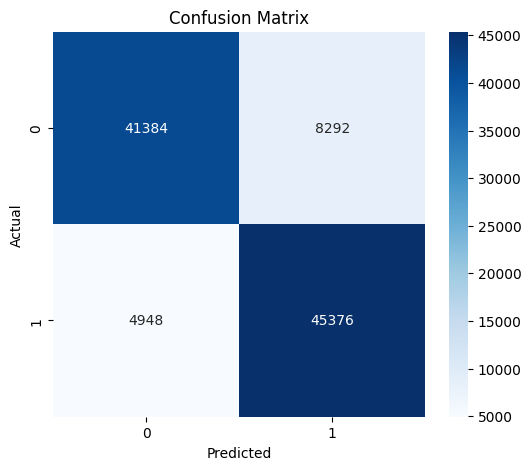

In [22]:

# 4. Confusion Matrix
plot_confusion_matrix(y_test, y_pred)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


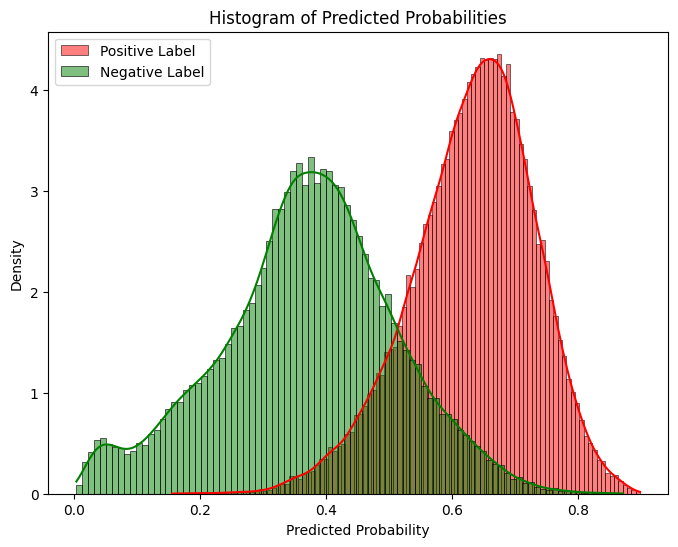

In [23]:

# 5. Histogram of predicted probabilities
plot_pred_prob_histogram(y_test, y_prob)